# Tutorial

Variance reduction of a treatment effect estimate by subtracting out variance that a pre-experiment covariate can explain. A smaller variance means narrower confidence intervals and lower p-values in the presence of a treatment effect.

`pfngouin` applies this idea using a learned model (Linear, XGBoost, or TabPFN) fitted on the combined control + treatment data. We then compare methods on two key metrics:

- **p-value** — did we reach significance?
- **95% CI width** — how precise is our effect estimate? (narrower = less uncertainty)

In [ ]:
import sys

sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg
from data_generation import make_experiment_data

import pfngouin as ppg

example_data = make_experiment_data(N=500, p_treatment=0.2, effect=1.0, seed=42)
control   = example_data["control"]
treatment = example_data["treatment"]
X_ctrl    = example_data["X_ctrl"]
X_trt     = example_data["X_trt"]

print(f"Control:   n={len(control)},  mean={control.mean():.2f},  std={control.std():.2f}")
print(f"Treatment: n={len(treatment)}, mean={treatment.mean():.2f}, std={treatment.std():.2f}")
print(f"Raw mean difference: {treatment.mean() - control.mean():.3f}")

Control:   n=402,  mean=14.33,  std=10.40
Treatment: n=98, mean=17.69, std=12.16
Raw mean difference: 3.364


In [2]:
import time

N_RUNS = 5
all_results = []

for run in range(N_RUNS):
    seed = 42 + run
    data = make_experiment_data(N=500, p_treatment=0.5, effect=1.0, seed=seed)
    control   = data["control"]
    treatment = data["treatment"]
    X_ctrl    = data["X_ctrl"]
    X_trt     = data["X_trt"]

    run_results = []

    # ── No adjustment (baseline) ──────────────────────────────────────────────
    t0 = time.perf_counter()
    r = pg.ttest(treatment, control)
    elapsed = time.perf_counter() - t0
    r = r.assign(method="No adjustment", var_reduction=0.0, elapsed_s=elapsed, run=run)
    run_results.append(r)

    # ── Linear model ──────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    r = ppg.ttest(
        control, treatment,
        covariates_control=X_ctrl,
        covariates_treatment=X_trt,
        model=ppg.LinearModel(),
        random_state=seed,
    )
    elapsed = time.perf_counter() - t0
    r = r.assign(method="LinearModel", elapsed_s=elapsed, run=run)
    run_results.append(r)

    # ── XGBoost (untuned) ─────────────────────────────────────────────────────
    t0 = time.perf_counter()
    r = ppg.ttest(
        control, treatment,
        covariates_control=X_ctrl,
        covariates_treatment=X_trt,
        model=ppg.XGBoostModel(tune=False),
        random_state=seed,
    )
    elapsed = time.perf_counter() - t0
    r = r.assign(method="XGBoostModel (untuned)", elapsed_s=elapsed, run=run)
    run_results.append(r)

    # ── XGBoost (tuned) ───────────────────────────────────────────────────────
    t0 = time.perf_counter()
    r = ppg.ttest(
        control, treatment,
        covariates_control=X_ctrl,
        covariates_treatment=X_trt,
        model=ppg.XGBoostModel(tune=True, n_iter=250, cv=5, n_jobs=-1),
        random_state=seed,
    )
    elapsed = time.perf_counter() - t0
    r = r.assign(method="XGBoostModel (tuned)", elapsed_s=elapsed, run=run)
    run_results.append(r)

    # ── TabPFN ────────────────────────────────────────────────────────────────
    t0 = time.perf_counter()
    r = ppg.ttest(
        control, treatment,
        covariates_control=X_ctrl,
        covariates_treatment=X_trt,
        model=ppg.TabPFNModel(),
        random_state=seed,
    )
    elapsed = time.perf_counter() - t0
    r = r.assign(method="TabPFNModel", elapsed_s=elapsed, run=run)
    run_results.append(r)

    all_results.append(pd.concat(run_results, ignore_index=True))
    print(f"Run {run + 1}/{N_RUNS} done")

raw = pd.concat(all_results, ignore_index=True)
raw["ci_width"] = raw["CI95"].apply(lambda x: x[1] - x[0])

Found existing access token, reusing it for authentication.

Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]


Run 1/5 done


Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]


Run 2/5 done


...

Run 3/5 done


Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]


Run 4/5 done


Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]
Processing: 100%|██████████| [00:00<00:00]


Run 5/5 done


In [3]:
METHOD_ORDER = ["No adjustment", "LinearModel", "XGBoostModel (untuned)", "XGBoostModel (tuned)", "TabPFNModel"]

agg = (
    raw.groupby("method")[["p_val", "ci_width", "var_reduction", "elapsed_s"]]
    .agg(["mean", "sem"])
)
agg.columns = ["_".join(c) for c in agg.columns]
agg = agg.reindex(METHOD_ORDER)

display(
    agg[["p_val_mean", "p_val_sem", "ci_width_mean", "ci_width_sem", "elapsed_s_mean", "elapsed_s_sem"]]
    .round(4)
    .rename(columns={
        "p_val_mean": "p-value (mean)", "p_val_sem": "p-value (SE)",
        "ci_width_mean": "CI width (mean)", "ci_width_sem": "CI width (SE)",
        "elapsed_s_mean": "runtime s (mean)", "elapsed_s_sem": "runtime s (SE)",
    })
)

,p-value (mean),p-value (SE),CI width (mean),CI width (SE),runtime s (mean),runtime s (SE)
method,,,,,,
No adjustment,0.3728,0.1145,3.802,0.0102,0.0077,0.0009
LinearModel,0.2038,0.1029,3.042,0.0206,0.0429,0.0347
XGBoostModel (untuned),0.1293,0.0442,3.272,0.0107,0.5891,0.0604
XGBoostModel (tuned),0.1168,0.0418,3.022,0.0280,148.7133,2.2244
TabPFNModel,0.1226,0.0342,2.960,0.0195,6.7927,0.0843


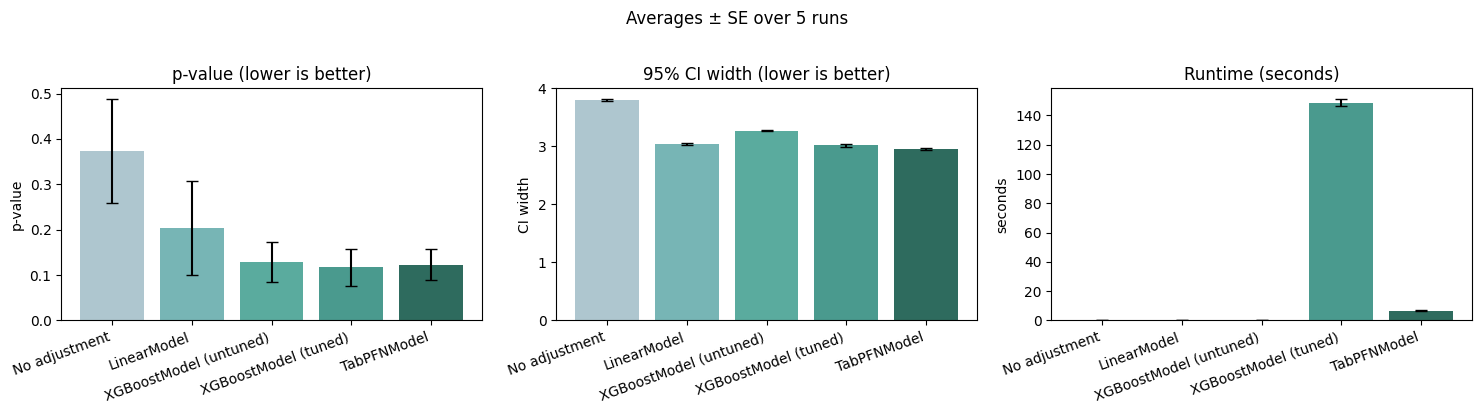

In [4]:
methods = METHOD_ORDER
colors = ["#aec6cf", "#77b5b5", "#5aab9e", "#4a9a8e", "#2e6b5e"]
x = range(len(methods))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def bar_with_se(ax, means, sems, title, ylabel):
    ax.bar(x, means, color=colors, zorder=2)
    ax.errorbar(x, means, yerr=sems, fmt="none", color="black", capsize=4, linewidth=1.5, zorder=3)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha="right")

bar_with_se(axes[0], agg["p_val_mean"], agg["p_val_sem"],   "p-value (lower is better)",    "p-value")
bar_with_se(axes[1], agg["ci_width_mean"], agg["ci_width_sem"], "95% CI width (lower is better)", "CI width")
bar_with_se(axes[2], agg["elapsed_s_mean"], agg["elapsed_s_sem"], "Runtime (seconds)",            "seconds")

fig.suptitle(f"Averages ± SE over {N_RUNS} runs", y=1.02)
fig.tight_layout()
plt.savefig("tutorial_results.png", bbox_inches="tight")